In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales:{ collection.count_documents({}):,}")

total sales:5,000


# Q7: How many unique products are sold by the business, and what are their names?

In [18]:
from pprint import pprint

pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "Total sales": {"$sum": "$items.quantity"}
        }
    },
    {
        "$sort": { "_id": 1}
    }
]

products = list(collection.aggregate(pipeline))

pprint(products)

print(f"Total unique products: {len(products)}")

products_df = pd.DataFrame(products)
products_df.rename(columns={"_id": "Product Name"}, inplace=True)   

products_df

[{'Total sales': 6918, '_id': 'backpack'},
 {'Total sales': 25493, '_id': 'binder'},
 {'Total sales': 25078, '_id': 'envelopes'},
 {'Total sales': 6793, '_id': 'laptop'},
 {'Total sales': 20727, '_id': 'notepad'},
 {'Total sales': 13766, '_id': 'pens'},
 {'Total sales': 12092, '_id': 'printer paper'}]
Total unique products: 7


,Product Name,Total sales
0,backpack,6918
1,binder,25493
2,envelopes,25078
3,laptop,6793
4,notepad,20727
5,pens,13766
6,printer paper,12092


In [14]:
product_names = products_df["Product Name"].tolist()
for i in product_names:
    print(i)

backpack
binder
envelopes
laptop
notepad
pens
printer paper


## Code for Visualization

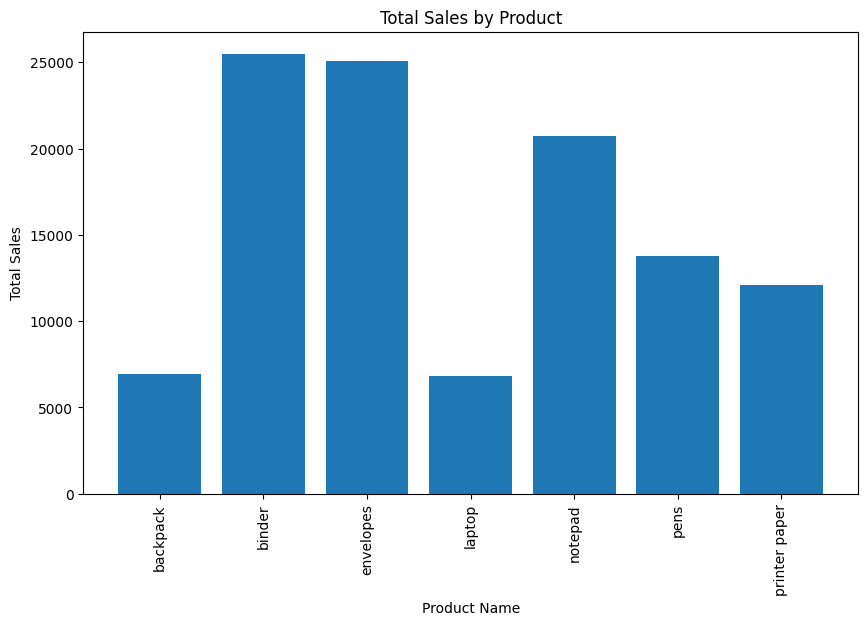

In [20]:
plt.figure(figsize=(10, 6))
plt.bar(products_df["Product Name"], products_df["Total sales"])
plt.title("Total Sales by Product")

plt.ylabel("Total Sales")
plt.xlabel("Product Name")  

plt.xticks(rotation=90)

plt.show()